An idea came to me:

At equilibrium the correlation function is given as 

$$\braket{ \sigma \sigma} = C(r)$$

and we know that away from equilibriu mthe function takes a scale invariant form:

$$\braket{ \sigma \sigma  }= C(r) f( r/\xi)$$

Now then, we also have an understanding that this form is still somewhat accurate with quenches, eg. 

$$\braket{\sigma \sigma }=  C(r) f(r/\sqrt{\tau}) $$

is it then true that 

$$\rho  \dot{=} \braket{\sigma\sigma} - \braket{\sigma\sigma(\tau)}= C(r) (1-f(r/\sqrt{\tau}))=  C(1) ( 1- f(1/\sqrt{\tau}))?$$

If this is true, then we have a direct (!) connection between the structure factor and the kibble zurek effect.

What is a good way to test this? Presumably with the $$\sigma^x, \sigma^z$$ ops. 

In [1]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift
import kblock_ising_model as kb

import kibble_zurek as kz
import time
from scipy.special import gamma


from joblib import Parallel, delayed

foldername = "Figures/"

def xx(state,r):
#A function to just easily calculate the distance correlation functions
    return array([kb.sigma_general([0,i],state,k ) for i in tqdm(r)])
def kxx(state,r):
    return array([kz.sigma_general([0,i],state) for i in r])

#Calculating correlation functions can take a really long time so we load it instead

def load_data():
    taus = np.load("data/tau_correlation_functions.npz")["b"]
    Y = np.load("data/tau_correlation_functions.npz")["a"]
    deltas = np.load("data/delta_correlation_functions.npz")["b"]
    X = np.load("data/delta_correlation_functions.npz")["a"]
    return deltas, X, taus, Y
##################
#Constants
#################
r = np.arange(-100,100)
L = 500
delta_values = np.logspace(-3,-1,25)
taus = np.logspace(-2,3.5,20)
k = kb.k_vals(L)

#Calculate Equilibrium Correlation functions in thermodynamic limit for comparison
xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"
C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])
###
#Ground State Generation
###
kb_states = [kb.U(k,1+d) for d in tqdm(delta_values)]
###
# Kibble Zurek State Generation
###
kz_states = Parallel(n_jobs=-1)(delayed(kz.state)(L, tau, 0) for tau in tqdm(taus))
####
# Kibble Zurek Correlation Function Generation (Takes 15 minutes on mac)
#X = [xx(state,r) for state in kb_states]
#Y = [kxx(state,r) for state in tqdm(kz_states)]

# #Scaling Collapse
# for x,d in zip(X,delta_values):
#     scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])
# legend()
# yscale("log")

deltas, kb_correlation_funcs, taus, kz_correlation_funcs = load_data()
rhos = array([sigma_x([0,1])-kz.sigma_general([0,1],s) for s in kz_states])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 20/20 [00:00<00:00, 264.92it/s]
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:219: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


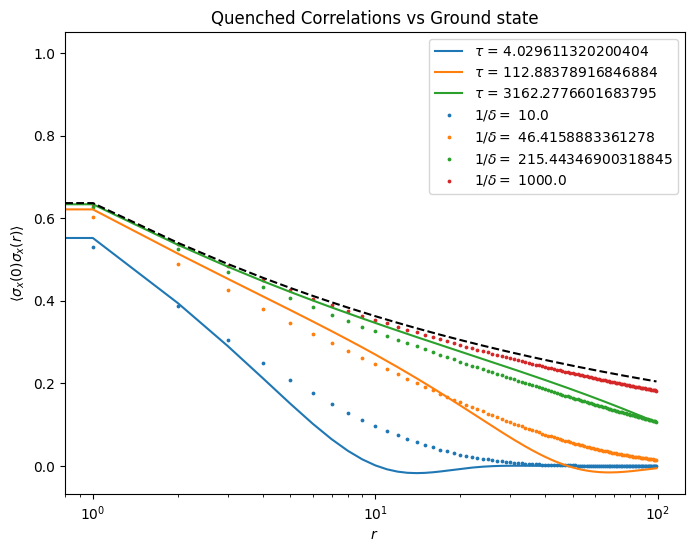

In [3]:
plt.figure(figsize=(8,6))
for t,y in zip(taus[9::5],kz_correlation_funcs[9::5]):
    plot(r,(y),label=rf"$\tau$ = {t}")
plot(r,C_xx,"--k")

for d, x in zip(delta_values[::-1][::8], kb_correlation_funcs[::-1][::8]):
     scatter(r,x,s=3,label=rf"$1/\delta=$ {1/d}" )
title(r"Quenched Correlations vs Ground state")
ylabel(xx_lab)
xlabel(r"$r$")
#yscale("log")
xscale("log")
legend()
show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/105110468.py:3: RuntimeWarning: invalid value encountered in power
  plot(r/xi,abs(y*r**(1/4)),label=tau)


(1.0, 50.0)

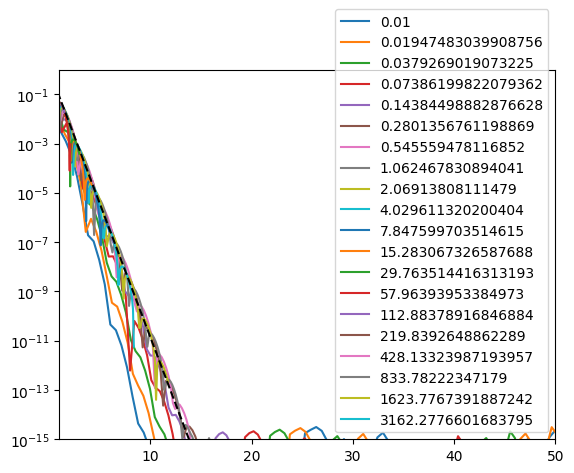

In [4]:
for y,tau,rho in zip(kz_correlation_funcs,taus,rhos):
    xi = 1/rho
    plot(r/xi,abs(y*r**(1/4)),label=tau)
legend()
plot(r,exp(-r*2.5),"--k")
#xscale('log')
ylim(0.000000000000001,1)
yscale('log')
xlim(1,50)

[]

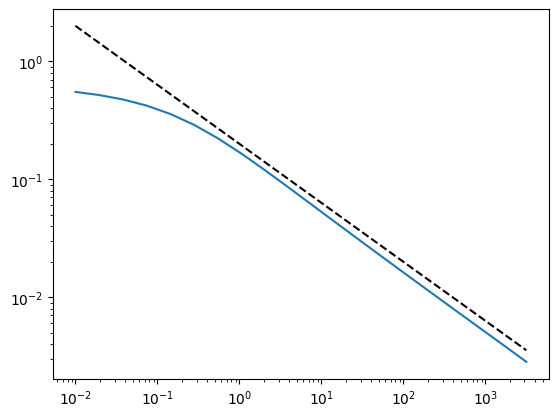

In [5]:
plot(taus,rhos)
plot(taus,taus**(-1/2)/sqrt(8*pi),"--k")
loglog()

# Characterize the function C(r)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2982351995.py:8: RuntimeWarning: invalid value encountered in power
  axs[0,1].plot(r,x*r**(1/4),label="d")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2982351995.py:13: RuntimeWarning: invalid value encountered in power
  axs[1,0].plot(r*d,x*r**(1/4))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2982351995.py:17: RuntimeWarning: invalid value encountered in power
  axs[1,1].scatter(r*d,x*r**(1/4),s=5)


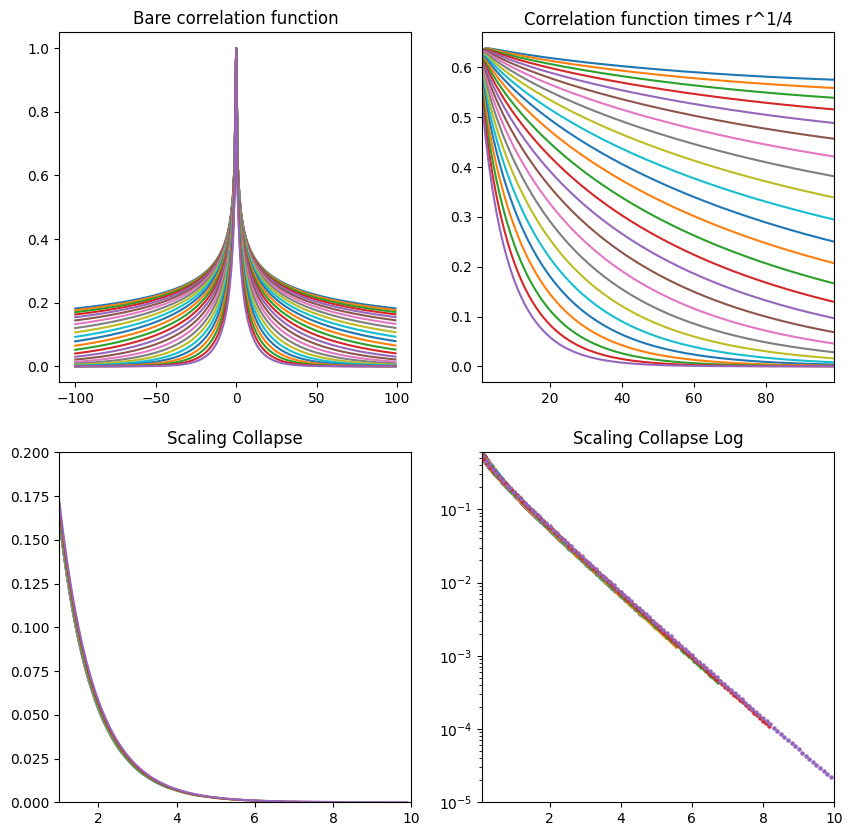

In [6]:
fig, axs = plt.subplots(2,2,figsize=(10,10))

for x ,d in zip(kb_correlation_funcs,delta_values):
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(r,x,label=d);

    axs[0,1].set_title("Correlation function times r^1/4")
    axs[0,1].plot(r,x*r**(1/4),label="d")
    axs[0,1].set_xlim(1,r.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].plot(r*d,x*r**(1/4))
    axs[1,0].set_xlim(1,10)
    axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(r*d,x*r**(1/4),s=5)
    axs[1,1].set_yscale("log")
    axs[1,1].set_xlim(.1,10)
    axs[1,1].set_ylim(0.00001,.6)
    #axs[0,0].legend()

Evidently the new function is a an exponential. Let's try fitting to determine its behaviour.

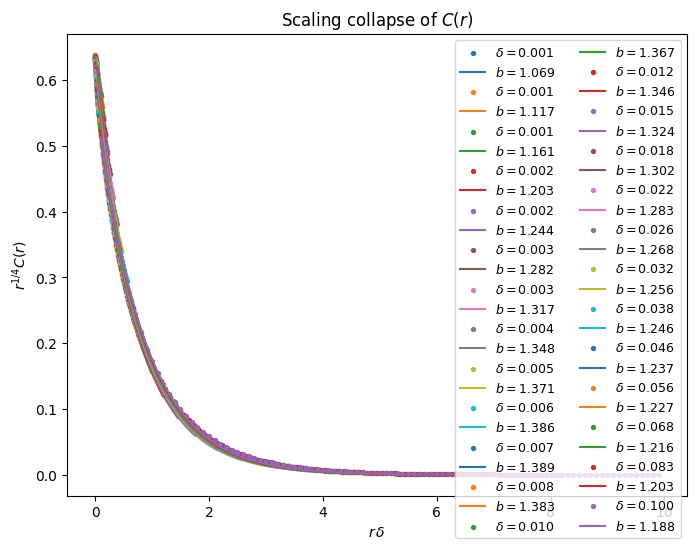

In [7]:
from scipy.optimize import curve_fit

def fit(x, a, b):
    return a * np.exp(-b * x)

plt.figure(figsize=(8,6))

for j, delta in enumerate(delta_values):
    mask = r > 0
    xfit = r[mask] * abs(delta)
    yfit = kb_correlation_funcs[j, mask] * r[mask]**(1/4)

    popt, _ = curve_fit(fit, xfit, yfit)
    a, b = popt
    scatter(xfit, yfit, s=8, label=fr"$\delta={delta:.3f}$")
    plot(xfit, fit(xfit, a, b), '-', label=fr"$b={b:.3f}$")

xlabel(r"$r\,\delta$")
ylabel(r"$r^{1/4}C(r)$")
title(r"Scaling collapse of $C(r)$")
legend(ncol=2, fontsize=9)
show()



# Now we fit to an exponential

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: divide by zero encountered in matmul
  cov_x = invR @ invR.T
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: invalid value encountered in matmul
  cov_x = invR @ invR.T


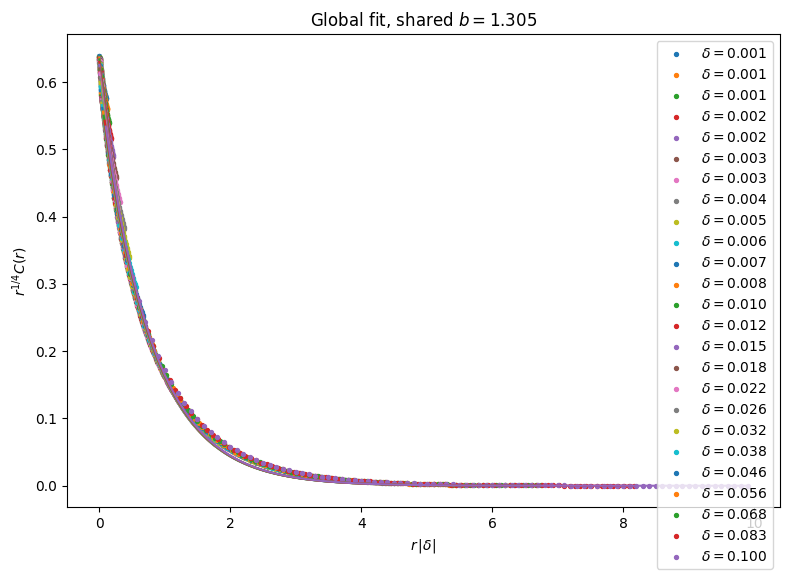

In [8]:

from scipy.optimize import curve_fit

def fit_global(all_x, *params):
    n = len(delta_values)
    a_list = params[:-1]
    b = params[-1]
    y = []
    for j in range(n):
        mask = r > 0
        xfit = r[mask] * np.abs(delta_values[j])
        y.append(a_list[j] * np.exp(-b * xfit))
    return np.concatenate(y)

# concatenate all data
x_all, y_all = [], []
for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * np.abs(delta_values[j])
    yfit = kb_correlation_funcs[j, mask] * r[mask]**(1/4)
    x_all.append(xfit)
    y_all.append(yfit)
x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

# initial guesses: all a=1, b=1
p0 = [1.0]*len(delta_values) + [1.0]
popt, _ = curve_fit(fit_global, x_all, y_all, p0=p0)
a_list = popt[:-1]
b = popt[-1]

plt.figure(figsize=(8,6))
for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * np.abs(delta_values[j])
    yfit = kb_correlation_funcs[j, mask] * r[mask]**(1/4)
    plt.scatter(xfit, yfit, s=8, label=fr"$\delta={delta_values[j]:.3f}$")
    plt.plot(xfit, a_list[j] * np.exp(-b * xfit), '-')
plt.xlabel(r"$r\,|\delta|$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title(fr"Global fit, shared $b={b:.3f}$")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
print(f"Shared decay constant b = {b:.6f}")


Shared decay constant b = 1.304521


# Characterize the function $C(r,\tau)$

A=0.6776, k=-0.3696, b=0.3714, phi=0.3944


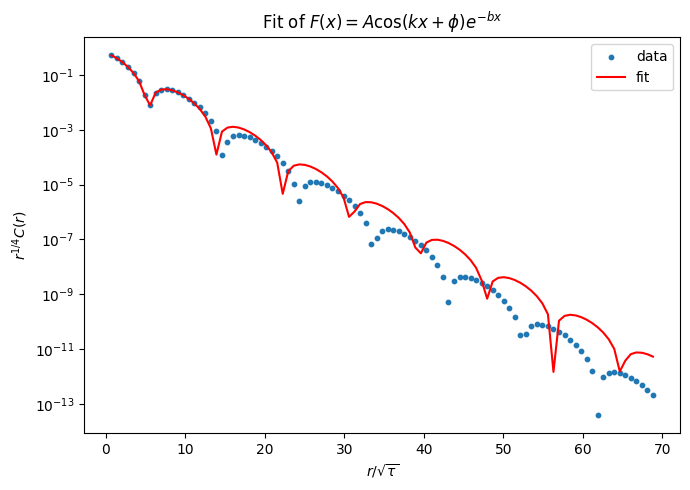

In [10]:
# define model: exponential decay with oscillations
def F_model(x, A, k, b, phi):
    return A * np.cos(k*abs(x) + phi) * np.exp(-b*abs(x))

# select first dataset
y = kz_correlation_funcs[8]
tau = taus[8]
mask = r > 0
xdata = r[mask] / np.sqrt(tau)
ydata = y[mask] * r[mask]**(1/4)
xtest = r[mask]/np.sqrt(taus[8])
# fit
p0 = [np.max(ydata), 1.0, 1.0, 0.0]
popt, _ = curve_fit(F_model, xdata, ydata, p0=p0, maxfev=10000)
A, k, b, phi = popt
print(f"A={A:.4f}, k={k:.4f}, b={b:.4f}, phi={phi:.4f}")

# plot
plt.figure(figsize=(7,5))
plt.scatter(xdata, abs(ydata), s=10, label="data")
plt.plot(xtest, abs(F_model(xtest, *popt)), 'r-', label="fit")
plt.xlabel(r"$r/\sqrt{\tau}$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title(r"Fit of $F(x) = A\cos(kx+\phi)e^{-bx}$")
yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

The above cell tells us that the decay is a mix of an exponetial, and an oscilltiory cosine like function. The fit is not perfect! But it caputres the general important features well.

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2654129245.py:9: RuntimeWarning: invalid value encountered in power
  axs[0,1].plot(r,y*r**(1/4),label="d")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2654129245.py:14: RuntimeWarning: invalid value encountered in power
  axs[1,0].scatter(r/(tau)**(1/2),y*r**(1/4),s=5)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/2654129245.py:18: RuntimeWarning: invalid value encountered in power
  axs[1,1].scatter(r/((tau)**(1/2)),abs(y*r**(1/4)),s=5)


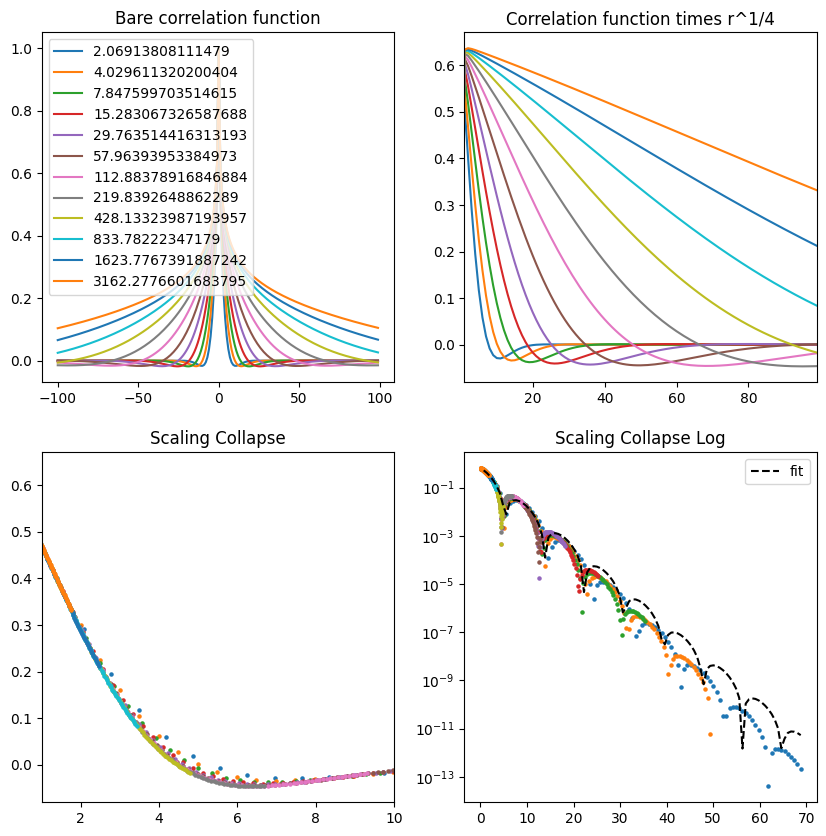

In [11]:
fig, axs = plt.subplots(2,2,figsize=(10,10))

for y ,tau,rho in zip(kz_correlation_funcs[8::1],taus[8::1],rhos[8::1]):
    xi = 1/rho
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(r,y,label=tau);

    axs[0,1].set_title("Correlation function times r^1/4")
    axs[0,1].plot(r,y*r**(1/4),label="d")
    axs[0,1].set_xlim(1,r.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(r/(tau)**(1/2),y*r**(1/4),s=5)
    axs[1,0].set_xlim(1,10)
    #axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(r/((tau)**(1/2)),abs(y*r**(1/4)),s=5)
    axs[1,1].set_yscale("log")
    #axs[1,1].set_xlim(.1,10)
    #axs[1,1].set_ylim(0.00001,.6)
    axs[0,0].legend()
axs[1,1].plot(xtest, abs(F_model(xtest, *popt)), '--k', label="fit")

axs[1,1].legend()

foldername = "Figures/"

filename = "tau_scaling_collapse.png"
#plt.savefig(foldername+filename)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/3907776675.py:6: RuntimeWarning: invalid value encountered in power
  axs[0, 1].scatter(r * d, x * r**(1/4), label=fr"{d:.3g}", s=5)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/3907776675.py:19: RuntimeWarning: invalid value encountered in power
  axs[1, 0].scatter(r / np.sqrt(tau), y * r**(1/4), label=fr"{tau:.1g}", s=5)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/3907776675.py:20: RuntimeWarning: invalid value encountered in power
  axs[1, 1].scatter(r / np.sqrt(tau), abs(y) * r**(1/4), s=5)


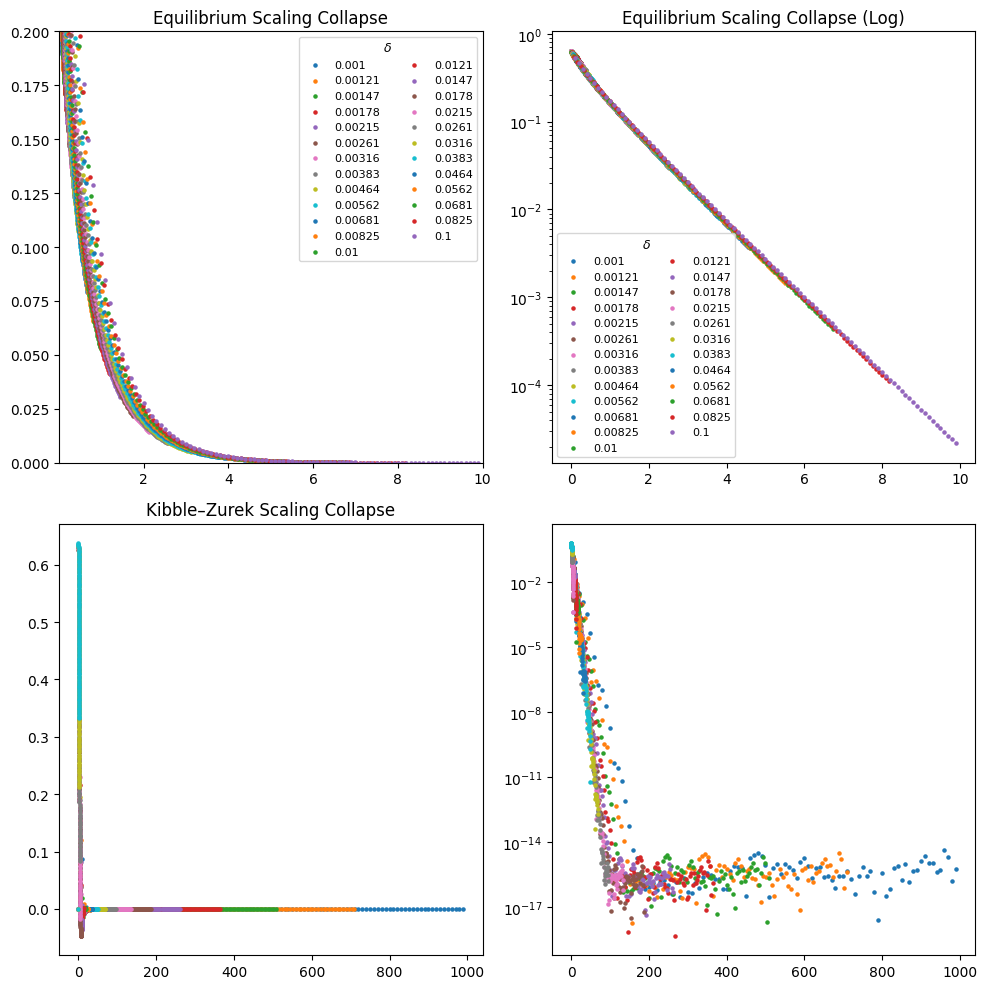

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# --- Top row ---
for x, d in zip(kb_correlation_funcs, delta_values):
    axs[0, 0].scatter(r * d, x, label=fr"{d:.3g}", s=5)
    axs[0, 1].scatter(r * d, x * r**(1/4), label=fr"{d:.3g}", s=5)

axs[0, 0].set_title("Equilibrium Scaling Collapse")
axs[0, 0].set_xlim(0.01, 10)
axs[0, 0].set_ylim(0, 0.2)
axs[0, 0].legend(title=r"$\delta$", fontsize=8, title_fontsize=9, loc="upper right", ncol=2)

axs[0, 1].set_title("Equilibrium Scaling Collapse (Log)")
axs[0, 1].set_yscale("log")
axs[0, 1].legend(title=r"$\delta$", fontsize=8, title_fontsize=9, loc="lower left", ncol=2)

# --- Bottom row: KZ (tau) scaling collapse ---
for y, tau in zip(kz_correlation_funcs, taus):
    axs[1, 0].scatter(r / np.sqrt(tau), y * r**(1/4), label=fr"{tau:.1g}", s=5)
    axs[1, 1].scatter(r / np.sqrt(tau), abs(y) * r**(1/4), s=5)

axs[1, 0].set_title("Kibble–Zurek Scaling Collapse")
axs[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()



# Now let's look at the structure factor

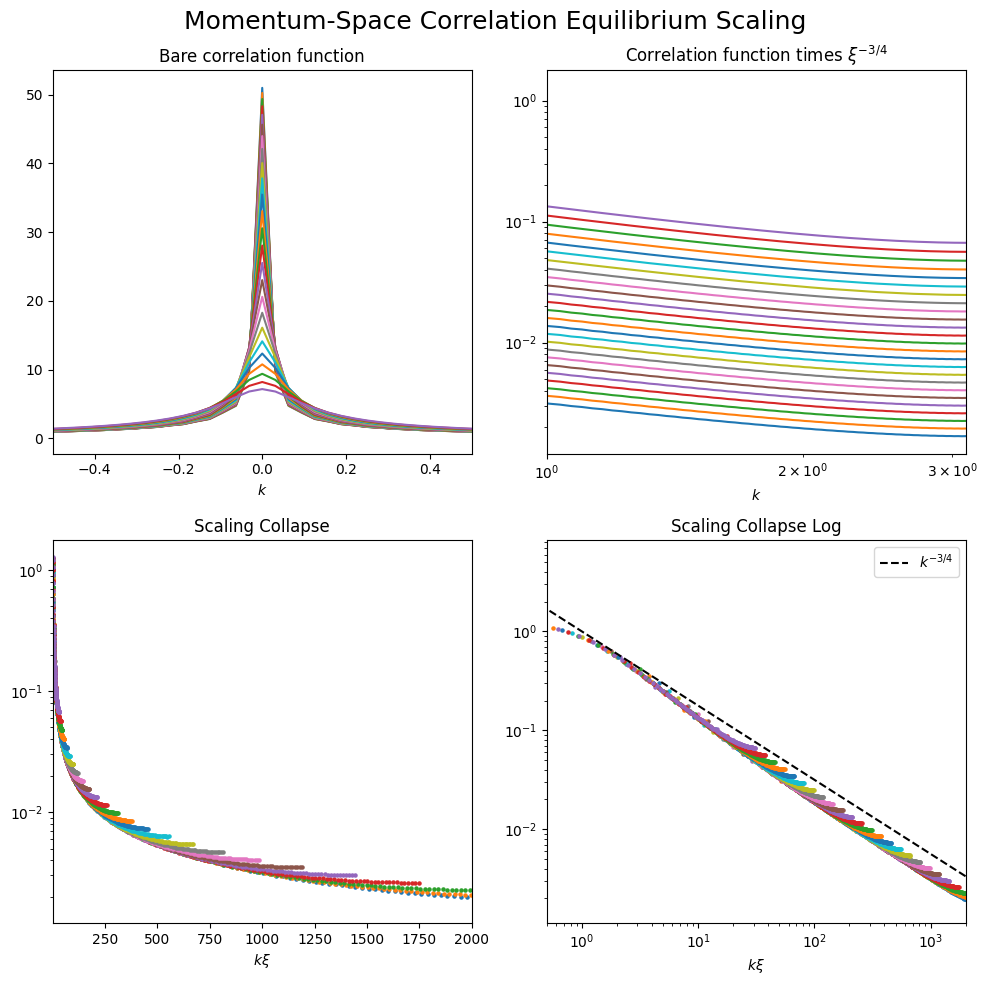

In [14]:
k = fftshift(fftfreq(len(r),1))*2*pi
kb_structure_factor = array([fftshift(fft(x)) for x in kb_correlation_funcs])
kz_structure_factor = array([fftshift(fft(y)) for y in kz_correlation_funcs])
fig, axs = plt.subplots(2,2,figsize=(10,10))

for x ,d in zip(kb_structure_factor,delta_values):
    xi = 1/d
    k_scaled = xi*k
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(k,abs(x),label=d);
    axs[0,0].set_xlim(-0.5,0.5)
    axs[0,1].set_title(r"Correlation function times $\xi^{-3/4}$")
    axs[0,1].plot(k,abs(x)*xi**(-3/4),label="d")
    axs[0,1].loglog()

    axs[0,1].set_xlim(1,k.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(k_scaled,abs(x)*xi**(-3/4),s=5)
    axs[1,0].set_yscale("log")
    axs[1,0].set_xlim(0.5,2000)
    #axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(k_scaled,abs(x)*xi**(-3/4),s=5)
    axs[1,1].set_yscale("log")
    axs[1,1].set_xscale("log")
    axs[1,1].set_xlim(.5,2000)
    axs[1,1].set_xlabel(r"$k \xi$")
    axs[1,0].set_xlabel(r"$k \xi$")
    axs[0,1].set_xlabel(r"$k$")
    axs[0,0].set_xlabel(r"$k$")

    # axs[1,1].set_ylim(0.00001,.6)
    # #axs[0,0].legend()
kkk = np.logspace(-1,3.5)

axs[1,1].plot(kkk,kkk**(-3/4),"--k",label=r"$k^{-3/4}$")
axs[1,1].legend()
fig.suptitle("Momentum-Space Correlation Equilibrium Scaling", fontsize=18)
plt.tight_layout()
plt.savefig(foldername+"delta_momentumspace_correlation_scaling.png")

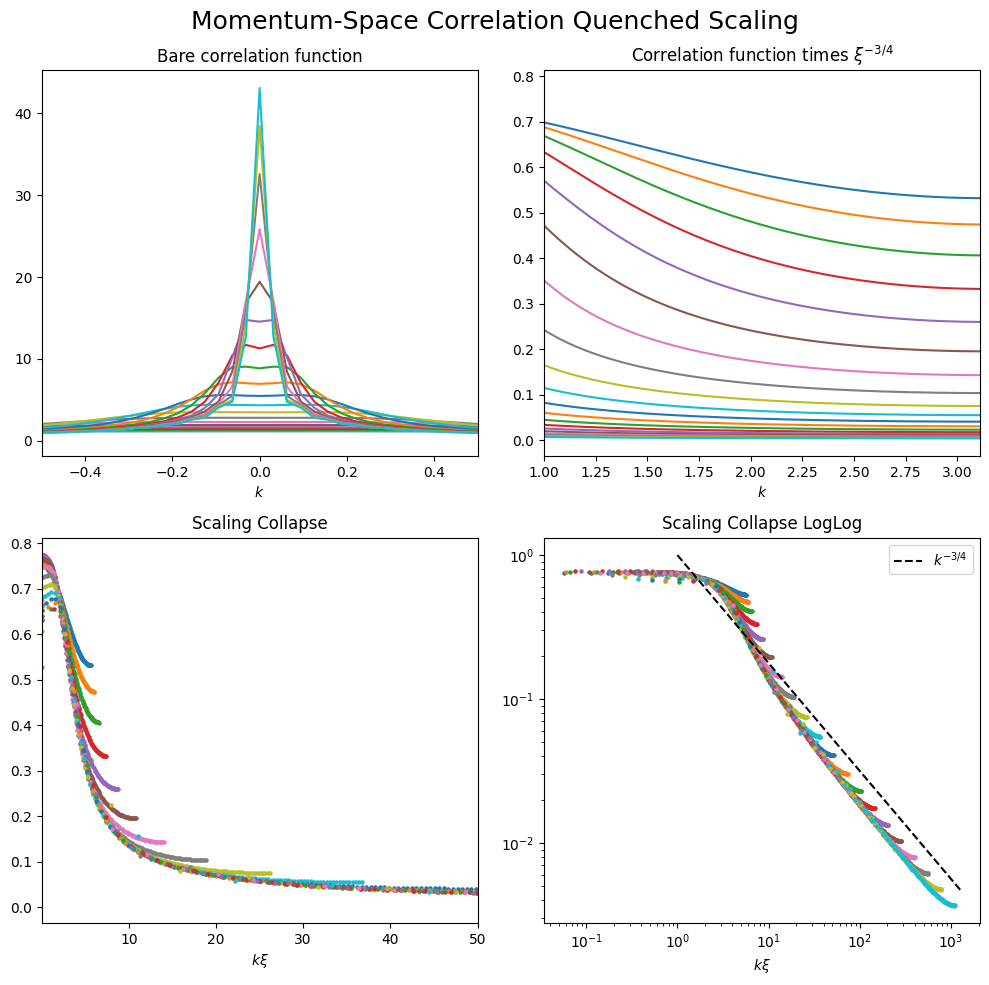

In [15]:


fig, axs = plt.subplots(2,2,figsize=(10,10))

for y ,tau,rho in zip(kz_structure_factor,taus,rhos):
    axs[0,0].set_title("Bare correlation function")
    xi = 1/rho
    k_scaled = k*xi
    axs[0,0].plot(k,abs(y),label=d);
    axs[0,0].set_xlim(-0.5,0.5)
    
    axs[0,1].set_title(r"Correlation function times $\xi^{-3/4}$")
    axs[0,1].plot(k,abs(y)*xi**(-3/4),label="d")
    axs[0,1].set_xlabel(r"$k $")

    #axs[0,1].loglog()

    axs[0,1].set_xlim(1,k.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(k_scaled,abs(y)*xi**(-3/4),s=5)
    axs[1,0].set_xlim(0.01,50)
    axs[1,0].set_xlabel(r"$k \xi$")
    axs[1,1].set_title("Scaling Collapse LogLog")
    axs[1,1].scatter(k_scaled,abs(y)*xi**(-3/4),s=5)
    axs[1,1].loglog()
   # axs[1,1].set_xlim(0.01,50)
    axs[1,1].set_xlabel(r"$k \xi$")
    axs[0,0].set_xlabel(r"$k $")

    # #axs[1,0].set_ylim(0,.2)
    # axs[1,1].set_title("Scaling Collapse Log")
    # axs[1,1].scatter(k*d,x*k**(1/4),s=5)
    #axs[1,0].set_yscale("log")
    # axs[1,1].set_xlim(.1,10)
    # axs[1,1].set_ylim(0.00001,.6)
    # #axs[0,0].legend()
fake_k = np.logspace(0,3.1,100)
axs[1,1].plot(fake_k,fake_k**(-3/4),"--k",label=r"$k^{-3/4}$")
axs[1,1].legend()
fig.suptitle("Momentum-Space Correlation Quenched Scaling", fontsize=18)
plt.tight_layout()
plt.savefig(foldername+"tau_momentumspace_correlation_scaling.png")

# Now we will fourier transform our ansatz for the quenched universal function, and see if we can recreate this caling factor

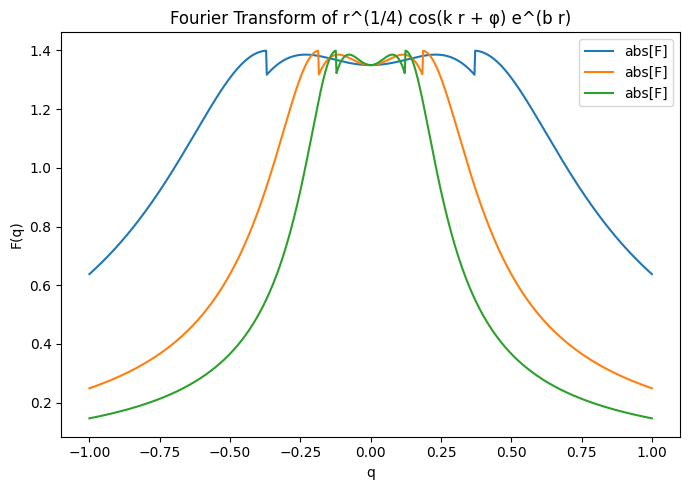

In [16]:
def FT_Sardine(q, A=0.6776, k=-0.3696, b=0.3714, phi=0.3944):
    """
    Fourier transform of r^(1/4) * cos(k*r + phi) * exp(b*r)
    for Re(b) < 0.
    """
    q = np.asarray(q, dtype=np.complex128)
    G = gamma(5/4)
    term1 = np.exp(1j * phi) * (-b - 1j * (q - k))**(-5/4)
    term2 = np.exp(-1j * phi) * (-b - 1j * (q + k))**(-5/4)
    return A * 0.5 * G * (term1 + term2)

# Sardine vector and plot
Sardine = np.linspace(-1, 1, 800)

plt.figure(figsize=(7,5))
Fvals = FT_Sardine(Sardine*1)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
Fvals = FT_Sardine(Sardine*2)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
Fvals = FT_Sardine(Sardine*3)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
plt.xlabel("q")
plt.ylabel("F(q)")
plt.title("Fourier Transform of r^(1/4) cos(k r + φ) e^(b r)")
plt.legend()
plt.tight_layout()
plt.show()


# Ansatz that captures essential physics

In [17]:
def F_model(x, A=0.6776, k=-0.3696, b=0.3714, phi=0.3944):
    return A * np.cos(k*x + phi) * np.exp(-b*x)


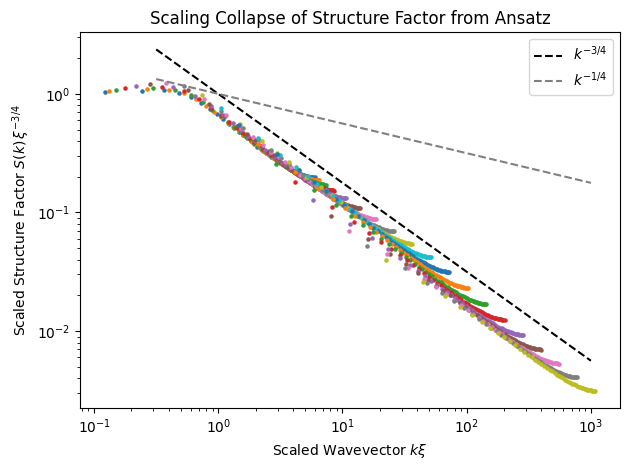

In [18]:
ansatz_r = np.arange(1, 101)
ansatz_k = fftshift(fftfreq(len(ansatz_r), ansatz_r[1] - ansatz_r[0])) * 2 * np.pi

for tau, rho in zip(taus[1:], rhos[1:]):
    xi = 1 / rho
    ansatz_Cr = F_model(ansatz_r * rho) * abs(ansatz_r)**(-1/4)
    ansatz_Sk = abs(fftshift(fft(ansatz_Cr)))
    plt.scatter(ansatz_k * xi, ansatz_Sk * xi**(-3/4), s=5)

plt.title("Scaling Collapse of Structure Factor from Ansatz")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Scaled Wavevector $k\xi$")
plt.ylabel(r"Scaled Structure Factor $S(k)\,\xi^{-3/4}$")

k_ref = np.logspace(-0.5, 3, 100)
plt.plot(k_ref, k_ref**(-3/4), "--k", label=r"$k^{-3/4}$")
plt.plot(k_ref, k_ref**(-1/4), "--", color="gray", label=r"$k^{-1/4}$")

plt.legend()
plt.tight_layout()
plt.show()


Now, we will see if we can connect it to the kible Zurek Effect

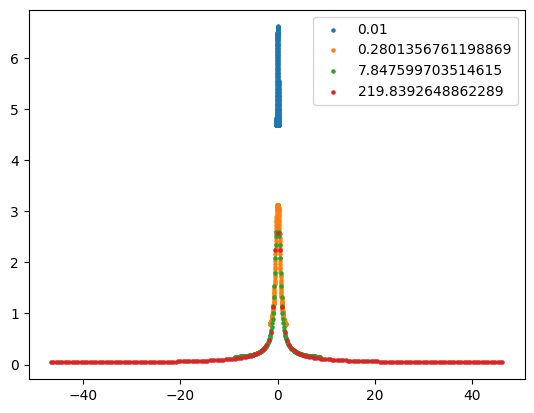

In [19]:
for tau,y in zip(taus[::5],kz_correlation_funcs[::5]):
    xi = sqrt(tau)


    k_rescale = k*xi
    G_f = fftshift(fft(y))

    scatter(k_rescale,abs(G_f)*xi**(-3/4),s=5,label=tau)
legend()

In [20]:
len(f)

NameError: name 'f' is not defined

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10523/389795946.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


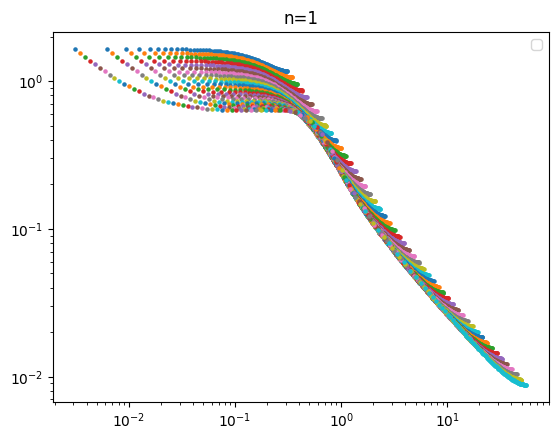

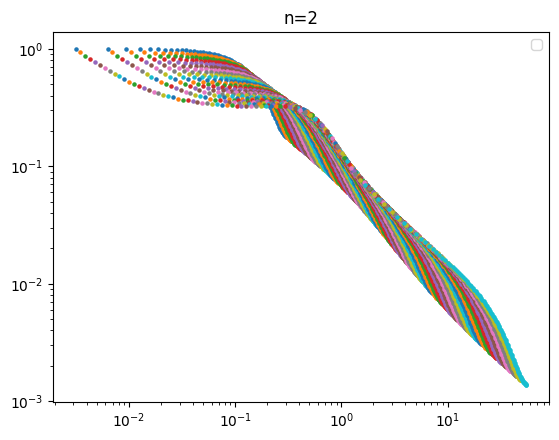

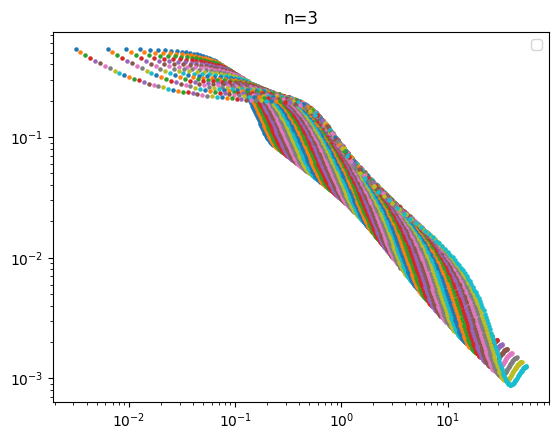

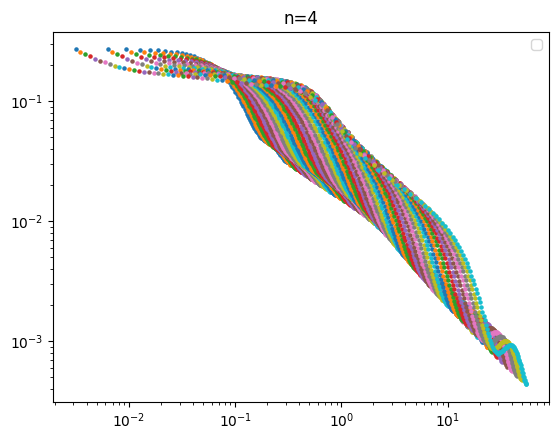

In [21]:
tau_pp = np.logspace(-2, 2.5, 50)
file_indices = [0,1,2,3]

for j in file_indices:
    g = np.load(f"data/PP_n1_4.npy")[j]
    plt.figure()
    for i, tau in zip(g, tau_pp):
        f = fftshift(fft(i))
        scatter(k * sqrt(tau), abs(f)/(j+1)*tau**(-3/8),s=5)# * sqrt(tau)**(-3/4), s=5)
    legend()
    loglog()
    title(f"n={j+1}")


In [22]:

r_high_fid = np.arange(-1600, 1600)

C_xx_hf = Parallel(n_jobs=-1)(
    delayed(sigma_x)([0, ri]) for ri in tqdm(r_high_fid, desc="Computing σₓσₓ")
)
C_xx_hf = np.array(C_xx_hf)

#Z =sum(abs(S_xx))

#Z_xx = S_xx/Z

Computing σₓσₓ:   0%|          | 0/3200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow enco

KeyboardInterrupt: 

In [ ]:
S_xx = fftshift(fft(C_xx_hf))
k_hf = fftshift(fftfreq(len(r_high_fid),1))*2*pi
Z =sum(abs(S_xx))
Z_xx = S_xx/Z
len(C_xx_hf)

3200

In [255]:
xis_analytic = 2*pi*sqrt(2*taus)
cut_off = rhos**(1.)

[]

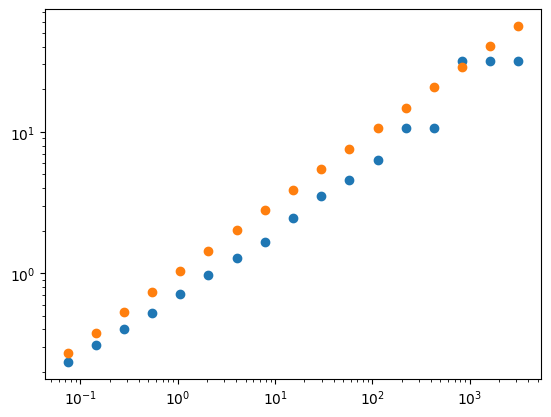

In [326]:
import numpy as np
from scipy.interpolate import interp1d

def fwhm(x, y):
    y = np.abs(y)
    half = np.max(y) / 2.0
    indices = np.where(np.diff(np.sign(y - half)))[0]
    if len(indices) >= 2:
        x1, x2 = x[indices[0]], x[indices[-1]]
        return x2 - x1
    else:
        return np.nan


dat = [1/fwhm(k,abs(kz_structure_factor[i])) for i in range(3,len(taus))]

scatter(taus[3:],dat)
scatter(taus[3:],taus[3:]**(1/2))
loglog()

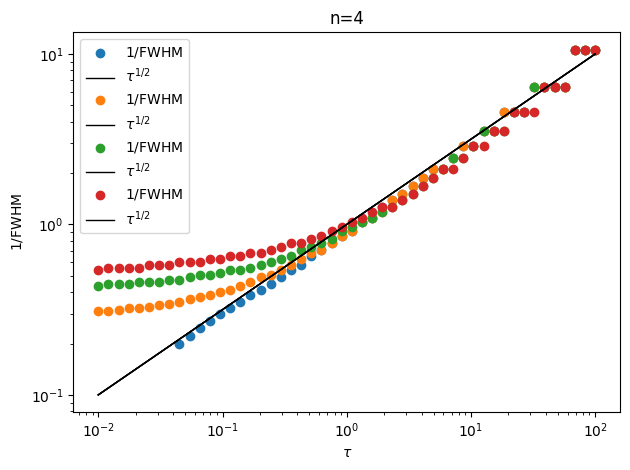

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

def fwhm(x, y):
    y = np.abs(y)
    half = np.max(y) / 2.0
    idx = np.where(np.diff(np.sign(y - half)))[0]
    if len(idx) >= 2:
        return x[idx[-1]] - x[idx[0]]
    return np.nan

tau_pp = np.logspace(-2, 2, 50)
file_indices = [0, 1, 2, 3]

plt.figure()

for j in file_indices:
    g = np.load("data/PP_n1_4.npy", allow_pickle=True)[j]
    widths = []
    for i in g:
        f = fftshift(fft(i))
        widths.append(fwhm(k, np.abs(f)))
    xi = 1 / np.array(widths)

    plt.scatter(tau_pp, xi, label=r"$1/\mathrm{FWHM}$")
    plt.plot(tau_pp, np.sqrt(tau_pp), label=r"$\tau^{1/2}$", color="k", lw=1)
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title(fr"n={j+1}")
    plt.xlabel(r"$\tau$")
    plt.ylabel(r"$1/\mathrm{FWHM}$")
    plt.tight_layout()
plt.show()


/tmp/ipykernel_36459/825460291.py:2: RuntimeWarning: divide by zero encountered in power
  plot(k_hf,abs(k_hf)**(-3/4))


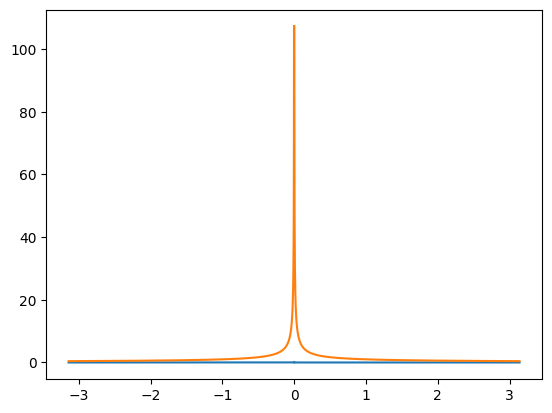

In [290]:
plot(k_hf,abs(Z_xx))
plot(k_hf,abs(k_hf)**(-3/4))
#loglog()

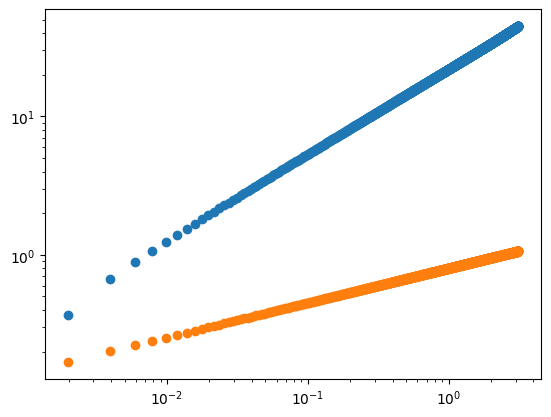

In [287]:
#plot(taus,rhos)
#plot(taus,cut_off)
dat = []
cut_off = k_hf[k_hf>0]
for Lam in cut_off:
    mask  = abs(k_hf)< Lam
    dat += [sum(sqrt(abs(Z_xx[mask])))]
scatter(cut_off,dat)
scatter(cut_off,cut_off**(1/4)/1.25)
xscale("log")
yscale("log")

[]

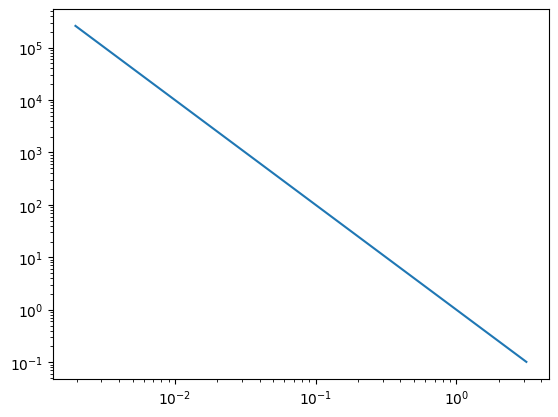

In [286]:
plot(cut_off,cut_off**(-2.))
loglog()

In [36]:
s = kz_states[0]

c = array([kz.P_n_correlations(1,i,s) for i in r])



/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:219: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


(-2.0, 2.0)

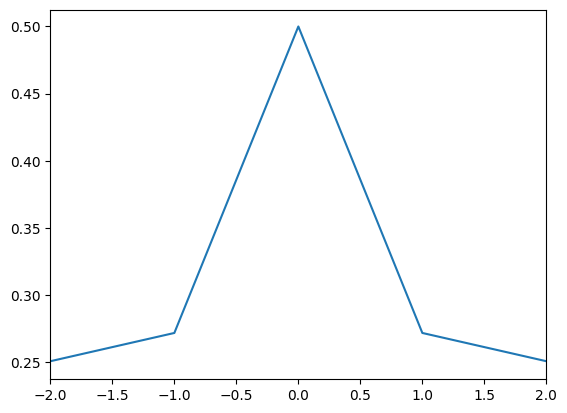

In [37]:
plot(r,c)

xlim(-2,2)